Codigo .csv a .json

In [ ]:
import pandas as pd

# 1. Definir los nombres exactos de las 13 columnas en orden
nombres_columnas = [
    'equipo', 
    'dorsal', 
    'nombre', 
    'posicion', 
    'fecha_nacimiento', 
    'edad', 
    'nacionalidad', 
    'altura', 
    'pie_dominante', 
    'fecha_llegada', 
    'club_procedente', 
    'fecha_contrato', 
    'valor_mercado'
]

# 2. Leer el CSV indicando el separador (;), la codificación (latin-1) y sin cabecera
df = pd.read_csv('futarg.csv', sep=';', encoding='latin-1', header=None, names=nombres_columnas)

# 3. Mostrar una vista previa rápida para verificar que quedó bien ordenado
print("--- Vista previa de los datos limpios ---")
print(df[['nombre', 'equipo', 'posicion', 'edad']].head())

# 4. Exportar a JSON correctamente estructurado
df.to_json('datos.json', orient='records', indent=4, force_ascii=False)

print("\n✅ ¡Éxito! El archivo 'futarg.csv' se convirtió y guardó como 'datos.json' perfectamente ordenado.")

Graficos matlib

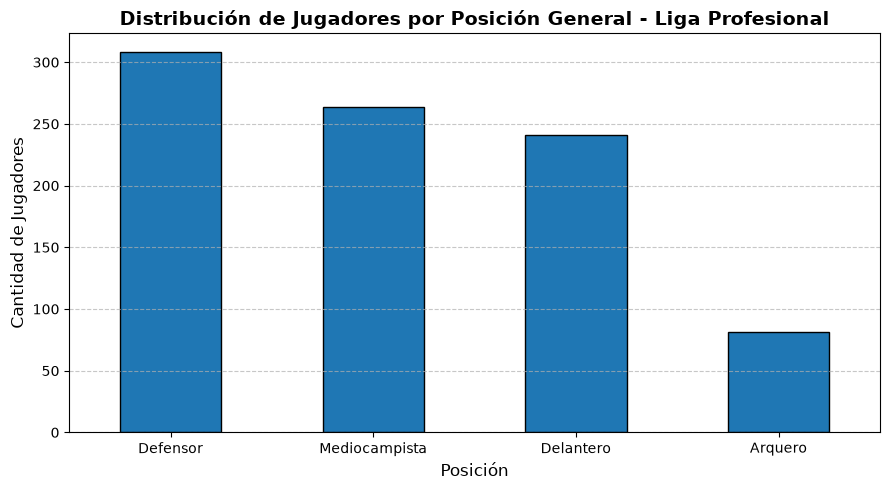

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar los datos desde el JSON generado
df = pd.read_json('datos.json')

# 2. Función para agrupar las posiciones específicas en 4 categorías generales
def categorizar_posicion(posicion):
    pos = str(posicion).lower()
    
    if 'portero' in pos or 'arquero' in pos:
        return 'Arquero'
    elif 'defensa' in pos or 'lateral' in pos:
        return 'Defensor'
    elif 'mediocentro' in pos or 'pivote' in pos or 'interior' in pos or 'mediapunta' in pos:
        return 'Mediocampista'
    elif 'delantero' in pos or 'extremo' in pos:
        return 'Delantero'
    else:
        return 'Otro'

# Aplicamos la función para crear una nueva columna con la categoría limpia
df['posicion_general'] = df['posicion'].apply(categorizar_posicion)

# 3. Contar los jugadores por esta nueva categoría general
jugadores_por_posicion = df['posicion_general'].value_counts()

# 4. Generar el gráfico de barras mejorado
plt.figure(figsize=(9, 5))
jugadores_por_posicion.plot(kind='bar', color='#1f77b4', edgecolor='black')
plt.title('Distribución de Jugadores por Posición General - Liga Profesional', fontsize=14, fontweight='bold')
plt.xlabel('Posición', fontsize=12)
plt.ylabel('Cantidad de Jugadores', fontsize=12)
plt.xticks(rotation=0)  # Al ser solo 4, quedan mejor horizontales
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

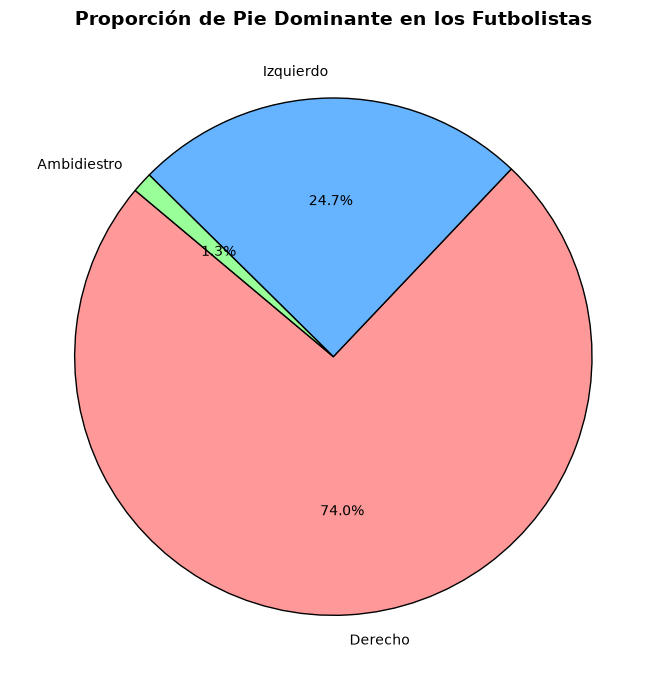

In [6]:
# --- GRÁFICO 2: Proporción de Pie Dominante (Gráfico de Torta / Circular) ---

# Nos aseguramos de usar la columna exacta 'pie_dominante' del JSON
df['pie_dominante_limpio'] = df['pie_dominante'].astype(str).str.strip().str.capitalize()

# Contamos las frecuencias
pie_counts = df['pie_dominante_limpio'].value_counts()

# Generamos el gráfico de torta
plt.figure(figsize=(7, 7))
pie_counts.plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=140,
    colors=['#ff9999', '#66b3ff', '#99ff99'],
    wedgeprops={'edgecolor': 'black'}
)
plt.title('Proporción de Pie Dominante en los Futbolistas', fontsize=14, fontweight='bold')
plt.ylabel('') # Oculta la etiqueta del eje y para mayor prolijidad
plt.tight_layout()
plt.show()